# Check Sampling distributions

Check that sampling triple phase space distributions is equivalent to their functional form. Both for rejection sampling and inverse cdf.

In [3]:
import sys
sys.path.append("../../")

In [33]:
from probab3.commands.common.formulas import triple_phase_space
from probab3.commands.common.formulas.general import *

num_of_samples = 1000

triple = triple_phase_space.TripleSystem(MSun, MSun, MSun, EB(MSun, MSun, AU), LB_from_aBeB(MSun, MSun, AU, 0.5), 2.5)

ellip_rej_samples = triple.ellip123.sample(size=num_of_samples, rejection=True)
ellip_invcdf_samples = triple.ellip123.sample(size=num_of_samples, rejection=False)
hyper_rej_samples = triple.hyper123.sample(size=num_of_samples, rejection=True)
hyper_invcdf_samples = triple.hyper123.sample(size=num_of_samples, rejection=False)

c:\Users\dinam\AppData\Local\Programs\Python\Python38\lib\site-packages\scipy\integrate\quadpack.py:463: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


In [58]:
def get_x_y_of_dist(samples, index):
    samled_index = [sample[index] for sample in samples]
    counts, bins = np.histogram(samled_index, bins=10)
    x_values = [0.5*(bins[i]+bins[i+1]) for i in range(len(bins)-1)]

    return x_values, counts

In [51]:
ellip_rej_eB_samples = [(eB_from_EBLB(MSun, MSun, sample[1], sample[2]),) for sample in ellip_rej_samples]
ellip_invcdf_eB_samples = [(eB_from_EBLB(MSun, MSun, sample[1], sample[2]),) for sample in ellip_invcdf_samples]
hyper_rej_eB_samples = [(eB_from_EBLB(MSun, MSun, sample[1], sample[2]),) for sample in hyper_rej_samples]
hyper_invcdf_eB_samples = [(eB_from_EBLB(MSun, MSun, sample[1], sample[2]),) for sample in hyper_invcdf_samples]

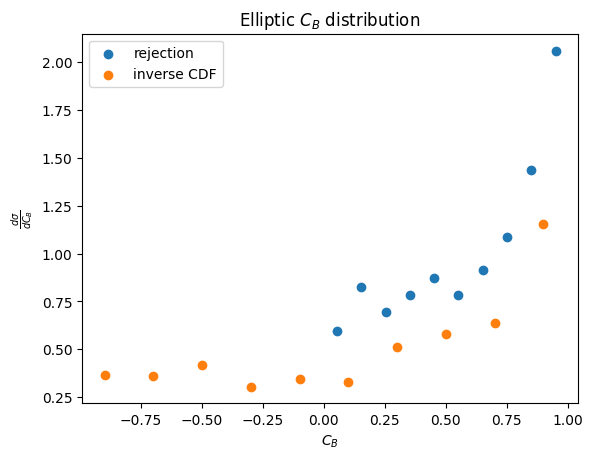

In [68]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(ellip_rej_samples, 0)

dx = x_values_rej[1]-x_values_rej[0]

plt.scatter(x_values_rej, counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(ellip_invcdf_samples, 0)

dx_invcdf = x_values_invcdf[1]-x_values_invcdf[0]

plt.scatter(x_values_invcdf, counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$C_B$")
plt.ylabel(r"$\frac{d\sigma}{dC_B}$")
plt.title(r"Elliptic $C_B$ distribution")
plt.legend()
plt.show()

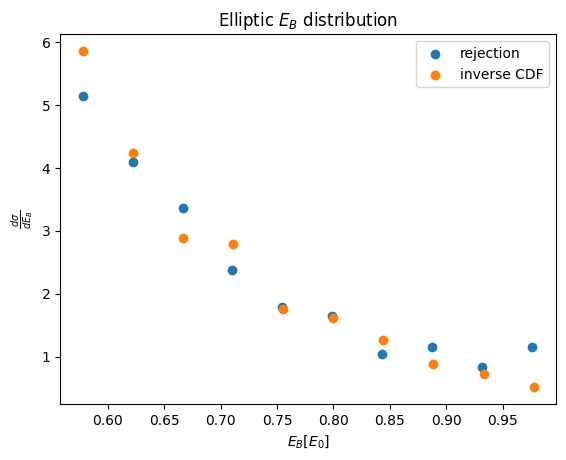

In [66]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(ellip_rej_samples, 1)

dx = np.abs((x_values_rej[1]-x_values_rej[0])/EB(MSun, MSun, AU))

plt.scatter(np.array(x_values_rej)/EB(MSun, MSun, AU), counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(ellip_invcdf_samples, 1)

dx_invcdf = np.abs((x_values_invcdf[1]-x_values_invcdf[0])/EB(MSun, MSun, AU))

plt.scatter(np.array(x_values_invcdf)/EB(MSun, MSun, AU), counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$E_B [E_0]$")
plt.ylabel(r"$\frac{d\sigma}{dE_B}$")
plt.title(r"Elliptic $E_B$ distribution")
plt.legend()
plt.show()

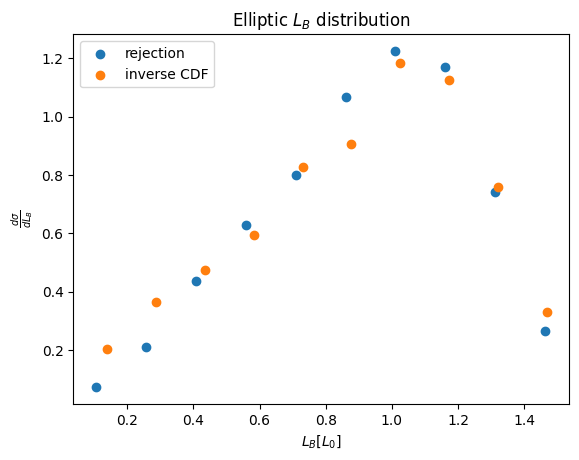

In [70]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(ellip_rej_samples, 2)

dx = np.abs((x_values_rej[1]-x_values_rej[0])/LB_from_aBeB(MSun, MSun, AU, 0.5))

plt.scatter(np.array(x_values_rej)/LB_from_aBeB(MSun, MSun, AU, 0.5), counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(ellip_invcdf_samples, 2)

dx_invcdf = np.abs((x_values_invcdf[1]-x_values_invcdf[0])/LB_from_aBeB(MSun, MSun, AU, 0.5))

plt.scatter(np.array(x_values_invcdf)/LB_from_aBeB(MSun, MSun, AU, 0.5), counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$L_B [L_0]$")
plt.ylabel(r"$\frac{d\sigma}{dL_B}$")
plt.title(r"Elliptic $L_B$ distribution")
plt.legend()
plt.show()

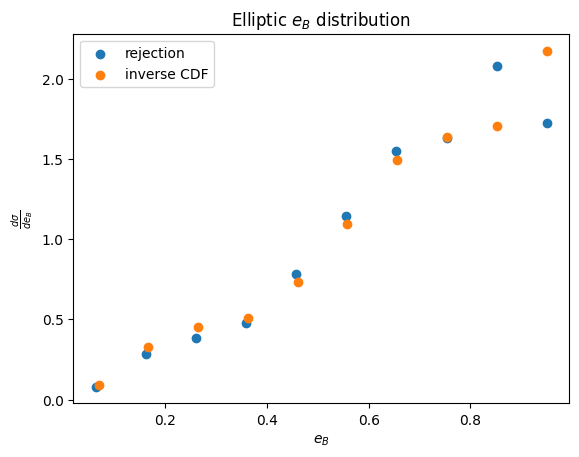

In [65]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(ellip_rej_eB_samples, 0)

dx = x_values_rej[1]-x_values_rej[0]

plt.scatter(np.array(x_values_rej), counts_rej/(num_of_samples*dx), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(ellip_invcdf_eB_samples, 0)

dx_invcdf = x_values_invcdf[1]-x_values_invcdf[0]

plt.scatter(np.array(x_values_invcdf), counts_invcdf/(num_of_samples*dx_invcdf), label="inverse CDF")

plt.xlabel(r"$e_B $")
plt.ylabel(r"$\frac{d\sigma}{de_B}$")
plt.title(r"Elliptic $e_B$ distribution")
plt.legend()
plt.show()

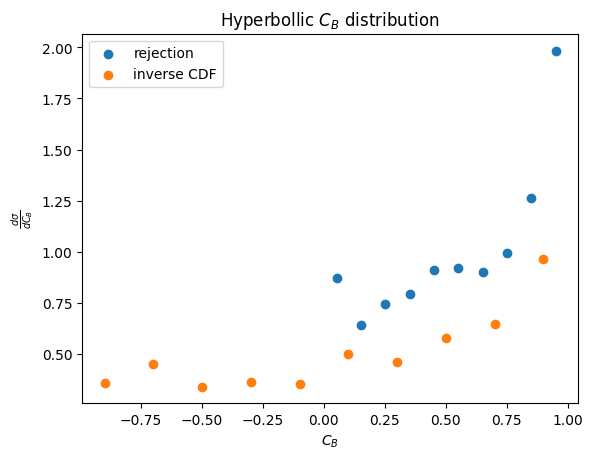

In [71]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(hyper_rej_samples, 0)

dx = x_values_rej[1]-x_values_rej[0]

plt.scatter(x_values_rej, counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(hyper_invcdf_samples, 0)

dx_invcdf = x_values_invcdf[1]-x_values_invcdf[0]

plt.scatter(x_values_invcdf, counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$C_B$")
plt.ylabel(r"$\frac{d\sigma}{dC_B}$")
plt.title(r"Hyperbollic $C_B$ distribution")
plt.legend()
plt.show()

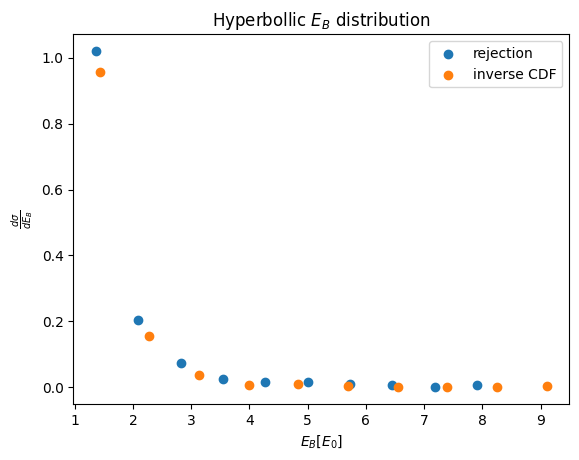

In [72]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(hyper_rej_samples, 1)

dx = np.abs((x_values_rej[1]-x_values_rej[0])/EB(MSun, MSun, AU))

plt.scatter(np.array(x_values_rej)/EB(MSun, MSun, AU), counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(hyper_invcdf_samples, 1)

dx_invcdf = np.abs((x_values_invcdf[1]-x_values_invcdf[0])/EB(MSun, MSun, AU))

plt.scatter(np.array(x_values_invcdf)/EB(MSun, MSun, AU), counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$E_B [E_0]$")
plt.ylabel(r"$\frac{d\sigma}{dE_B}$")
plt.title(r"Hyperbollic $E_B$ distribution")
plt.legend()
plt.show()

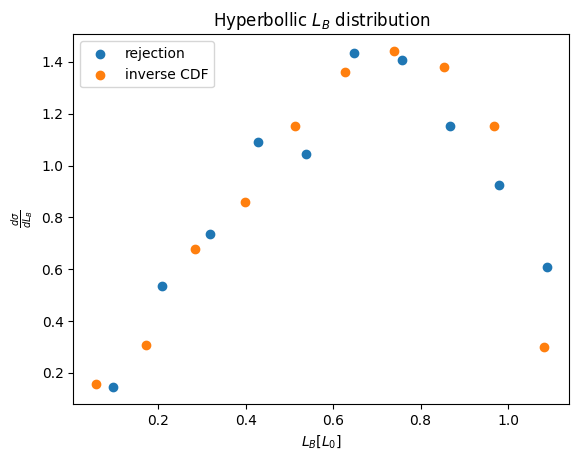

In [73]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(hyper_rej_samples, 2)

dx = np.abs((x_values_rej[1]-x_values_rej[0])/LB_from_aBeB(MSun, MSun, AU, 0.5))

plt.scatter(np.array(x_values_rej)/LB_from_aBeB(MSun, MSun, AU, 0.5), counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(hyper_invcdf_samples, 2)

dx_invcdf = np.abs((x_values_invcdf[1]-x_values_invcdf[0])/LB_from_aBeB(MSun, MSun, AU, 0.5))

plt.scatter(np.array(x_values_invcdf)/LB_from_aBeB(MSun, MSun, AU, 0.5), counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$L_B [L_0]$")
plt.ylabel(r"$\frac{d\sigma}{dL_B}$")
plt.title(r"Hyperbollic $L_B$ distribution")
plt.legend()
plt.show()

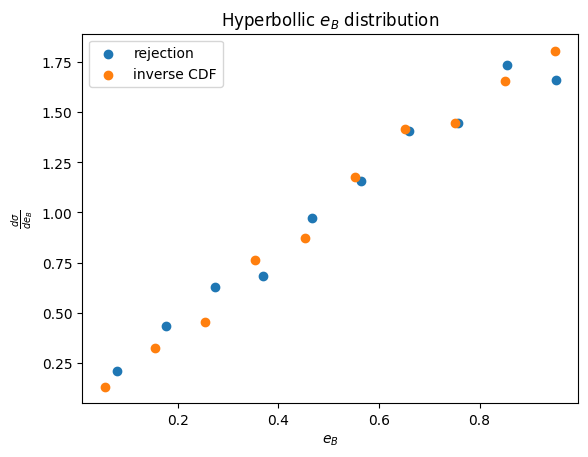

In [74]:
from matplotlib import pyplot as plt

x_values_rej, counts_rej = get_x_y_of_dist(hyper_rej_eB_samples, 0)

dx = x_values_rej[1]-x_values_rej[0]

plt.scatter(np.array(x_values_rej), counts_rej/(dx*num_of_samples), label="rejection")

x_values_invcdf, counts_invcdf = get_x_y_of_dist(hyper_invcdf_eB_samples, 0)

dx_invcdf = x_values_invcdf[1]-x_values_invcdf[0]

plt.scatter(np.array(x_values_invcdf), counts_invcdf/(dx_invcdf*num_of_samples), label="inverse CDF")

plt.xlabel(r"$e_B $")
plt.ylabel(r"$\frac{d\sigma}{de_B}$")
plt.title(r"Hyperbollic $e_B$ distribution")
plt.legend()
plt.show()